# TS-SatFire -- UNet3D v4 -- Burned Area Mapping

## What changed from HybridUNet v3

**Architecture change (the core fix):**
The HybridUNet with TemporalMLP + SpatialTransformerBlock is replaced with a clean
U-Net-3D. Every convolution is a 3D convolution operating over (T, H, W) simultaneously.
Time is treated as a spatial dimension. No attention, no MLP bottleneck, no custom
fusion modules. This matches the U-Net-3D baseline from the paper (Table 3, F1=0.834).

**Loss change (fixes the FP explosion):**
DistanceFocalDiceLoss with FIRE_CLASS_WEIGHT=300 is replaced with pure SoftDiceLoss.
Dice loss is inherently class-balanced -- it operates on overlap ratios so it naturally
penalises both FP and FN without needing explicit class weights. The v3 weighted focal CE
caused the model to predict fire everywhere to avoid missing true fire pixels.

**Input reshape change:**
v3 flattened (T, C, H, W) -> (T*C, H, W) for 2D convolutions.
v4 keeps the 3D shape (C, T, H, W) -- channels first, then (T, H, W) as the 3D volume.
This is the standard PyTorch layout for Conv3d: (N, C, D, H, W).

**Training schedule:**
OneCycleLR replaces cosine-annealing-to-zero. v3's cosine schedule reached LR=0 at
epoch 11 leaving the last 2 epochs useless. OneCycleLR warms up then decays smoothly
and never reaches exactly zero.

**Everything kept from v3:**
- Dataset class, data loading, thermal cummax aggregation (I4/I5 max over history)
- Normalisation statistics pipeline
- Train/val/test split logic (test = 2021 fires)
- MIN_FIRE_PIXELS and MAX_NEG_RATIO sample balancing
- VAL_FRACTION=0.15, TRAIN_INTERVAL=2, patch_size=128
- Checkpoint criterion: mean per-sample val F1
- All output file naming conventions

In [1]:
import os
import sys
import glob
import json
import math
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.auto import tqdm

import rasterio
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f'  GPU {i}  : {torch.cuda.get_device_name(i)}')

PyTorch  : 2.9.0+cu126
CUDA     : True
  GPU 0  : Tesla T4
  GPU 1  : Tesla T4


## Configuration

In [2]:
# Paths
DATA_ROOT  = '/kaggle/input/datasets/z789456sx/ts-satfire/ts-satfire'
OUTPUT_DIR = '/kaggle/working'
CKPT_PATH  = os.path.join(OUTPUT_DIR, 'unet3d_v4_ba_best.pt')
STATS_PATH = os.path.join(OUTPUT_DIR, 'norm_stats_v4.npz')
SAVE_FIGURES = True

# Resume from previous run
# Set this to the folder where you uploaded the previous run's weights on Kaggle.
# Example: '/kaggle/input/unet3d-v4-weights'
# Leave as None for a fresh training run from scratch.
RESUME_WEIGHTS_DIR = '/kaggle/input/unet3d-v4-weights'

# When resuming, use a lower peak LR to fine-tune rather than retrain from scratch.
# This is ignored on a fresh run (LR_MAX is used instead).
FINETUNE_LR_MAX = 1e-4

# Dataset
SEED          = 42
TIME_STEPS    = 2       # T=2 days per sample (paper ablation: TS=2 best for BA)
CHANS_PER_STEP = 26     # 6 spectral day + 2 night + 18 aux
PATCH_SIZE    = 128
VAL_FRACTION  = 0.15
TRAIN_INTERVAL = 2      # sliding window step for training samples
VAL_INTERVAL   = 4      # sliding window step for val/test
MIN_FIRE_PIXELS = 50    # minimum burned pixels to keep a positive sample
MAX_NEG_RATIO   = 3     # keep at most 3 negative samples per positive

# Model
BASE_CH  = 32           # U-Net base channel count; doubles each encoder stage
# Channel layout fed to Conv3d: (N, C, T, H, W)
# C = CHANS_PER_STEP (26), T = TIME_STEPS (2), H = W = PATCH_SIZE (128)

# Training
NUM_EPOCHS  = 30
BATCH_SIZE  = 8         # larger than v3 because no transformer memory overhead
LR_MAX      = 3e-4      # OneCycleLR peak learning rate
WEIGHT_DECAY = 1e-5

# Inference
INFER_THRESHOLD = 0.5   # correct default for Dice-trained model

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Device -- use DataParallel if two GPUs available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device   : {device}')
print(f'\nConfig summary:')
print(f'  TIME_STEPS={TIME_STEPS}, CHANS_PER_STEP={CHANS_PER_STEP}')
print(f'  PATCH_SIZE={PATCH_SIZE}, BASE_CH={BASE_CH}')
print(f'  BATCH_SIZE={BATCH_SIZE}, NUM_EPOCHS={NUM_EPOCHS}, LR_MAX={LR_MAX}')
print(f'  TRAIN_INTERVAL={TRAIN_INTERVAL}, VAL_FRACTION={VAL_FRACTION}')

Device   : cuda

Config summary:
  TIME_STEPS=2, CHANS_PER_STEP=26
  PATCH_SIZE=128, BASE_CH=32
  BATCH_SIZE=8, NUM_EPOCHS=30, LR_MAX=0.0003
  TRAIN_INTERVAL=2, VAL_FRACTION=0.15


## Dataset discovery and splits

In [3]:
if not os.path.isdir(DATA_ROOT):
    raise RuntimeError(f'Dataset not found at {DATA_ROOT}')

all_dirs = sorted([
    d for d in glob.glob(os.path.join(DATA_ROOT, '*'))
    if os.path.isdir(d)
])

REQUIRED = {'VIIRS_Day', 'VIIRS_Night', 'FirePred'}
fire_dirs, invalid = [], []
for d in all_dirs:
    sub = set(os.listdir(d))
    if REQUIRED.issubset(sub):
        fire_dirs.append(d)
    else:
        invalid.append(os.path.basename(d))

print(f'Total folders   : {len(all_dirs)}')
print(f'Valid fires     : {len(fire_dirs)}')
print(f'Invalid (skip)  : {len(invalid)}')

def fp_chan_count(fd):
    files = sorted(glob.glob(os.path.join(fd, 'FirePred', '*.tif')))
    if not files:
        return -1
    with rasterio.open(files[0]) as src:
        return src.count

bad       = [fd for fd in fire_dirs if fp_chan_count(fd) != 19]
fire_dirs = [fd for fd in fire_dirs if fd not in set(bad)]
print(f'Removed non-standard FirePred fires: {len(bad)}')
print(f'Usable fires    : {len(fire_dirs)}')

# Split: test = all 2021 fires, train/val from the rest
random.seed(SEED)
test_fires  = [fd for fd in fire_dirs if '2021' in os.path.basename(fd)]
train_pool  = [fd for fd in fire_dirs if fd not in set(test_fires)]
random.shuffle(train_pool)
n_val       = max(1, int(len(train_pool) * VAL_FRACTION))
val_fires   = train_pool[:n_val]
train_fires = train_pool[n_val:]

print(f'\nSplit summary:')
print(f'  train : {len(train_fires)} fires')
print(f'  val   : {len(val_fires)} fires')
print(f'  test  : {len(test_fires)} fires  (all 2021)')

# Save fire IDs for inference notebook
run_meta = {
    'version'      : 'v4',
    'TIME_STEPS'   : TIME_STEPS,
    'CHANS_PER_STEP': CHANS_PER_STEP,
    'PATCH_SIZE'   : PATCH_SIZE,
    'BASE_CH'      : BASE_CH,
    'INFER_THRESHOLD': INFER_THRESHOLD,
    'SEED'         : SEED,
    'train_fire_ids': [os.path.basename(f) for f in train_fires],
    'val_fire_ids'  : [os.path.basename(f) for f in val_fires],
    'test_fire_ids' : [os.path.basename(f) for f in test_fires],
}
with open(os.path.join(OUTPUT_DIR, 'run_meta_v4.json'), 'w') as f:
    json.dump(run_meta, f, indent=2)
print('Saved run_meta_v4.json')

Total folders   : 192
Valid fires     : 178
Invalid (skip)  : 14
Removed non-standard FirePred fires: 5
Usable fires    : 173

Split summary:
  train : 127 fires
  val   : 22 fires
  test  : 24 fires  (all 2021)
Saved run_meta_v4.json


## EDA

Surveying fires:   0%|          | 0/173 [00:00<?, ?it/s]

      n_days         ba_pos_days        
        mean min max        mean min max
split                                   
test    35.6  10  87        16.0   0  70
train   17.9   3  65         7.2   0  36
val     17.0   7  41         7.8   0  31


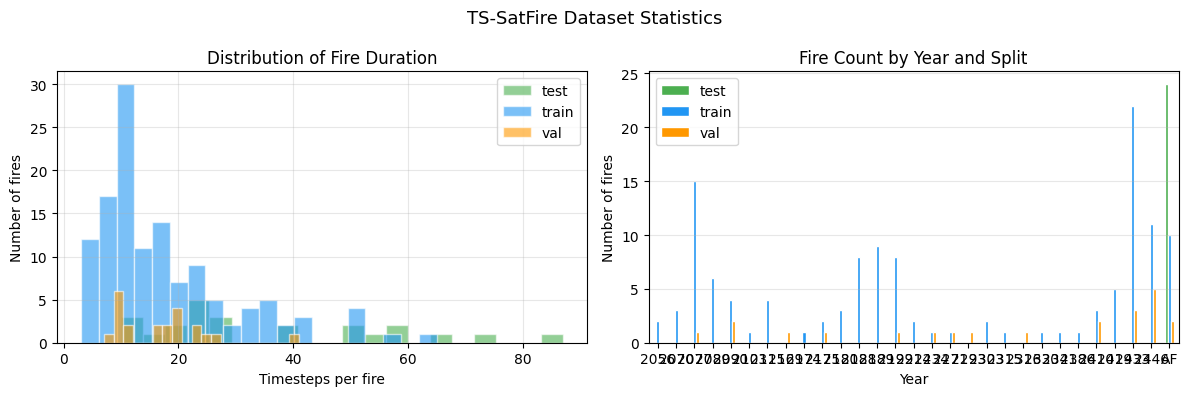

EDA complete.


In [4]:
records = []
for fd in tqdm(fire_dirs, desc='Surveying fires'):
    fid       = os.path.basename(fd)
    day_files = sorted(glob.glob(os.path.join(fd, 'VIIRS_Day', '*.tif')))
    fp_files  = sorted(glob.glob(os.path.join(fd, 'FirePred',  '*.tif')))
    year      = fid[:4] if fid[:4].isdigit() else 'AF'
    n_days    = len(day_files)
    with rasterio.open(day_files[0]) as src:
        h, w = src.height, src.width
    ba_pos = sum(
        1 for fp in fp_files
        if rasterio.open(fp).__enter__().read(3).max() > 0
    )
    split = ('test'  if fd in set(test_fires) else
             'val'   if fd in set(val_fires)  else 'train')
    records.append({'fire_id': fid, 'year': year, 'split': split,
                    'n_days': n_days, 'height': h, 'width': w,
                    'ba_pos_days': ba_pos})

df = pd.DataFrame(records)
print(df.groupby('split')[['n_days', 'ba_pos_days']].agg(['mean','min','max']).round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = {'train': '#2196F3', 'val': '#FF9800', 'test': '#4CAF50'}
for split, grp in df.groupby('split'):
    axes[0].hist(grp['n_days'], bins=20, alpha=0.6,
                 color=colors[split], label=split, edgecolor='white')
axes[0].set_xlabel('Timesteps per fire')
axes[0].set_ylabel('Number of fires')
axes[0].set_title('Distribution of Fire Duration')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

year_counts = df.groupby(['year', 'split']).size().unstack(fill_value=0)
year_counts.plot(kind='bar', ax=axes[1],
                 color=[colors[s] for s in year_counts.columns],
                 edgecolor='white')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of fires')
axes[1].set_title('Fire Count by Year and Split')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].legend()

plt.suptitle('TS-SatFire Dataset Statistics', fontsize=13)
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(os.path.join(OUTPUT_DIR, 'eda_stats_v4.png'), dpi=150, bbox_inches='tight')
plt.show()
print('EDA complete.')

## Normalisation statistics

Same two-pass percentile-clip pipeline as v3. Stats are recomputed fresh because
the channel layout is identical (26 channels per timestep) but we want a clean
v4-versioned file. If `norm_stats_v4.npz` already exists it is loaded directly.

In [5]:
def compute_norm_stats(fire_dirs, n_fires=25, n_days=3, seed=SEED,
                       clip_percentile=99):
    rng    = random.Random(seed)
    sample = rng.sample(fire_dirs, min(n_fires, len(fire_dirs)))

    all_vals = [[] for _ in range(CHANS_PER_STEP)]
    for fd in tqdm(sample, desc='Pass 1 / percentiles'):
        day_files = sorted(glob.glob(os.path.join(fd, 'VIIRS_Day', '*.tif')))
        for dp in random.sample(day_files, min(n_days, len(day_files))):
            date_str   = os.path.basename(dp).replace('_VIIRS_Day.tif', '')
            night_path = os.path.join(fd, 'VIIRS_Night', f'{date_str}_VIIRS_Night.tif')
            fp_path    = os.path.join(fd, 'FirePred',    f'{date_str}_FirePred.tif')
            with rasterio.open(dp) as src:
                d = src.read().astype(np.float32)
            spectral = d[:6]
            night = np.full((2, d.shape[1], d.shape[2]), np.nan, np.float32)
            if os.path.exists(night_path):
                with rasterio.open(night_path) as src:
                    night = src.read().astype(np.float32)[:2]
            H, W = spectral.shape[1], spectral.shape[2]
            if os.path.exists(fp_path):
                with rasterio.open(fp_path) as src:
                    fp = src.read().astype(np.float32)
                fp_t = torch.from_numpy(fp).unsqueeze(0)
                fp_t = F.interpolate(fp_t, size=(H, W), mode='nearest')
                fp   = fp_t.squeeze(0).numpy()
                aux  = np.concatenate([fp[:2], fp[3:]], axis=0)
            else:
                aux = np.zeros((18, H, W), np.float32)
            frame = np.concatenate([spectral, night, aux], axis=0)
            for c in range(CHANS_PER_STEP):
                vals = frame[c][np.isfinite(frame[c])].ravel()
                if vals.size > 0:
                    all_vals[c].append(vals[::max(1, len(vals)//2000)])

    lo_bounds = np.zeros(CHANS_PER_STEP, np.float32)
    hi_bounds = np.zeros(CHANS_PER_STEP, np.float32)
    for c in range(CHANS_PER_STEP):
        if all_vals[c]:
            v = np.concatenate(all_vals[c])
            lo_bounds[c] = np.percentile(v, 100 - clip_percentile)
            hi_bounds[c] = np.percentile(v, clip_percentile)

    sums    = np.zeros(CHANS_PER_STEP, np.float64)
    sq_sums = np.zeros(CHANS_PER_STEP, np.float64)
    counts  = np.zeros(CHANS_PER_STEP, np.float64)
    for fd in tqdm(sample, desc='Pass 2 / mean+std'):
        day_files = sorted(glob.glob(os.path.join(fd, 'VIIRS_Day', '*.tif')))
        for dp in random.sample(day_files, min(n_days, len(day_files))):
            date_str   = os.path.basename(dp).replace('_VIIRS_Day.tif', '')
            night_path = os.path.join(fd, 'VIIRS_Night', f'{date_str}_VIIRS_Night.tif')
            fp_path    = os.path.join(fd, 'FirePred',    f'{date_str}_FirePred.tif')
            with rasterio.open(dp) as src:
                d = src.read().astype(np.float32)
            spectral = d[:6]
            night = np.full((2, d.shape[1], d.shape[2]), np.nan, np.float32)
            if os.path.exists(night_path):
                with rasterio.open(night_path) as src:
                    night = src.read().astype(np.float32)[:2]
            H, W = spectral.shape[1], spectral.shape[2]
            if os.path.exists(fp_path):
                with rasterio.open(fp_path) as src:
                    fp = src.read().astype(np.float32)
                fp_t = torch.from_numpy(fp).unsqueeze(0)
                fp_t = F.interpolate(fp_t, size=(H, W), mode='nearest')
                fp   = fp_t.squeeze(0).numpy()
                aux  = np.concatenate([fp[:2], fp[3:]], axis=0)
            else:
                aux = np.zeros((18, H, W), np.float32)
            frame = np.concatenate([spectral, night, aux], axis=0)
            for c in range(CHANS_PER_STEP):
                vals = frame[c][np.isfinite(frame[c])]
                vals = np.clip(vals, lo_bounds[c], hi_bounds[c])
                sums[c]    += vals.sum()
                sq_sums[c] += (vals ** 2).sum()
                counts[c]  += vals.size

    means = (sums / np.maximum(counts, 1)).astype(np.float32)
    stds  = np.sqrt(np.maximum(
        sq_sums / np.maximum(counts, 1) - means ** 2, 1e-6
    )).astype(np.float32)
    return means, stds, lo_bounds, hi_bounds


if os.path.exists(STATS_PATH):
    data       = np.load(STATS_PATH)
    CHAN_MEANS  = data['means']
    CHAN_STDS   = data['stds']
    CLIP_LO     = data['clip_lo']
    CLIP_HI     = data['clip_hi']
    print(f'Loaded normalisation stats from {STATS_PATH}')
else:
    print('Computing normalisation statistics (2-pass with percentile clipping)...')
    CHAN_MEANS, CHAN_STDS, CLIP_LO, CLIP_HI = compute_norm_stats(train_fires)
    np.savez(STATS_PATH, means=CHAN_MEANS, stds=CHAN_STDS,
             clip_lo=CLIP_LO, clip_hi=CLIP_HI)
    print(f'Saved to {STATS_PATH}')

print(f'Means range: [{CHAN_MEANS.min():.3f}, {CHAN_MEANS.max():.3f}]')
print(f'Stds  range: [{CHAN_STDS.min():.3f},  {CHAN_STDS.max():.3f}]')

Computing normalisation statistics (2-pass with percentile clipping)...


Pass 1 / percentiles:   0%|          | 0/25 [00:00<?, ?it/s]

Pass 2 / mean+std:   0%|          | 0/25 [00:00<?, ?it/s]

Saved to /kaggle/working/norm_stats_v4.npz
Means range: [-0.123, 4260.868]
Stds  range: [0.002,  2406.180]


## Dataset

The dataset class is carried over from v3 with one key change in `__getitem__`:
instead of flattening the time dimension into channels `(T*C, H, W)`, the output
tensor is reshaped to `(C, T, H, W)` -- channels first, then the 3D volume `(T, H, W)`.
This is the layout expected by PyTorch `Conv3d`: `(N, C_in, D, H, W)` where D=T.

The thermal cummax aggregation (I4/I5 max over all previous days) is preserved exactly.
The distance weight map is removed since we are switching to pure Dice loss.

In [6]:
class TSSatFireDataset(Dataset):

    def __init__(self, fire_dirs, task='ba', time_steps=TIME_STEPS,
                 interval=1, patch_size=PATCH_SIZE,
                 means=None, stds=None,
                 clip_lo=None, clip_hi=None,
                 augment=False):
        self.task       = task
        self.T          = time_steps
        self.interval   = interval
        self.patch_size = patch_size
        self.means      = means
        self.stds       = stds
        self.clip_lo    = clip_lo
        self.clip_hi    = clip_hi
        self.augment    = augment
        self.samples    = []
        self._build_index(fire_dirs)

    def _build_index(self, fire_dirs):
        skipped    = 0
        n_pos      = 0
        n_neg      = 0
        n_neg_kept = 0
        rng = random.Random(SEED)

        for fd in fire_dirs:
            fp_files = sorted(glob.glob(os.path.join(fd, 'FirePred', '*.tif')))
            if fp_files:
                with rasterio.open(fp_files[0]) as src:
                    if src.count != 19:
                        skipped += 1
                        continue
            day_files = sorted(glob.glob(os.path.join(fd, 'VIIRS_Day', '*.tif')))
            if len(day_files) < self.T:
                skipped += 1
                continue
            n     = len(day_files)
            start = 0
            while start + self.T <= n:
                last_day = day_files[start + self.T - 1]
                date_str = os.path.basename(last_day).replace('_VIIRS_Day.tif', '')
                fp_path  = os.path.join(fd, 'FirePred', f'{date_str}_FirePred.tif')

                fire_px = 0
                if os.path.exists(fp_path):
                    with rasterio.open(fp_path) as src:
                        lbl = src.read(3).astype(np.float32)
                    H, W = lbl.shape
                    if self.patch_size and H > self.patch_size and W > self.patch_size:
                        r0 = (H - self.patch_size) // 2
                        c0 = (W - self.patch_size) // 2
                        p  = self.patch_size
                        lbl = lbl[r0:r0+p, c0:c0+p]
                    fire_px = int((lbl > 0).sum())

                is_positive = fire_px >= MIN_FIRE_PIXELS
                if is_positive:
                    n_pos += 1
                    keep = True
                else:
                    n_neg += 1
                    keep = rng.random() < 1.0 / (MAX_NEG_RATIO + 1)
                    if keep:
                        n_neg_kept += 1

                if keep:
                    self.samples.append({
                        'fire_dir'  : fd,
                        'day_files' : day_files,
                        'start'     : start,
                        'end'       : start + self.T - 1,
                    })
                start += self.interval

        print(f'Dataset: {len(self.samples)} samples '
              f'(T={self.T}, interval={self.interval}, skipped={skipped})')
        print(f'  positive patches : {n_pos}')
        print(f'  neg kept/total   : {n_neg_kept}/{n_neg}  '
              f'(ratio ~{MAX_NEG_RATIO}:1)')

    @staticmethod
    def _date(path):
        return os.path.basename(path).replace('_VIIRS_Day.tif', '')

    def _load_timestep(self, fd, day_path, H, W):
        date_str   = self._date(day_path)
        night_path = os.path.join(fd, 'VIIRS_Night', f'{date_str}_VIIRS_Night.tif')
        fp_path    = os.path.join(fd, 'FirePred',    f'{date_str}_FirePred.tif')

        with rasterio.open(day_path) as src:
            day_arr = src.read().astype(np.float32)
        spectral = day_arr[:6, :H, :W]

        if os.path.exists(night_path):
            with rasterio.open(night_path) as src:
                night = src.read().astype(np.float32)[:2, :H, :W]
        else:
            night = np.full((2, H, W), np.nan, np.float32)

        if os.path.exists(fp_path):
            with rasterio.open(fp_path) as src:
                fp = src.read().astype(np.float32)
            if fp.shape[1] != H or fp.shape[2] != W:
                fp = F.interpolate(torch.from_numpy(fp).unsqueeze(0),
                                   size=(H, W), mode='nearest').squeeze(0).numpy()
            # channel index 2 (fp band 3) is the BA label -- excluded from input
            aux = np.concatenate([fp[:2], fp[3:]], axis=0)  # (18, H, W)
        else:
            aux = np.zeros((18, H, W), np.float32)

        return np.concatenate([spectral, night, aux], axis=0)  # (26, H, W)

    def _load_label(self, fd, day_path, H, W):
        date_str = self._date(day_path)
        fp_path  = os.path.join(fd, 'FirePred', f'{date_str}_FirePred.tif')
        if os.path.exists(fp_path):
            with rasterio.open(fp_path) as src:
                ch2 = src.read(3).astype(np.float32)
            if ch2.shape[0] != H or ch2.shape[1] != W:
                ch2 = F.interpolate(
                    torch.from_numpy(ch2).unsqueeze(0).unsqueeze(0),
                    size=(H, W), mode='nearest').squeeze().numpy()
            return (ch2 > 0).astype(np.float32)
        return np.zeros((H, W), np.float32)

    def _thermal_cummax(self, fd, all_day_files, win_end, H, W):
        history = []
        for i in range(win_end + 1):
            dp       = all_day_files[i]
            date_str = self._date(dp)
            np_path  = os.path.join(fd, 'VIIRS_Night', f'{date_str}_VIIRS_Night.tif')
            with rasterio.open(dp) as src:
                i4d = src.read(4).astype(np.float32)[:H, :W]
                i5d = src.read(5).astype(np.float32)[:H, :W]
            if os.path.exists(np_path):
                with rasterio.open(np_path) as src:
                    i4n = src.read(1).astype(np.float32)[:H, :W]
                    i5n = src.read(2).astype(np.float32)[:H, :W]
            else:
                i4n = np.full((H, W), np.nan, np.float32)
                i5n = np.full((H, W), np.nan, np.float32)
            history.append(np.stack([i4d, i5d, i4n, i5n]))
        return history

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s         = self.samples[idx]
        fd        = s['fire_dir']
        all_files = s['day_files']
        win_start = s['start']
        win_end   = s['end']
        win_files = all_files[win_start : win_end + 1]

        shapes = []
        for dp in win_files:
            with rasterio.open(dp) as src:
                shapes.append((src.height, src.width))
        H = min(sh[0] for sh in shapes)
        W = min(sh[1] for sh in shapes)

        frames = [self._load_timestep(fd, dp, H, W) for dp in win_files]

        # Thermal cumulative max aggregation (paper Methods section)
        history = self._thermal_cummax(fd, all_files, win_end, H, W)
        for t in range(self.T):
            gd  = win_start + t
            cmx = np.nanmax(np.stack(history[:gd + 1]), axis=0)
            frames[t][3] = cmx[0]   # I4 day cummax
            frames[t][4] = cmx[1]   # I5 day cummax
            frames[t][6] = cmx[2]   # I4 night cummax
            frames[t][7] = cmx[3]   # I5 night cummax

        stack = np.stack(frames, axis=0)   # (T, C, H, W)

        # Percentile clip then normalise
        if self.clip_lo is not None:
            stack = np.clip(stack,
                            self.clip_lo[None, :, None, None],
                            self.clip_hi[None, :, None, None])
        if self.means is not None:
            stack = (stack - self.means[None, :, None, None]) / \
                     self.stds[ None, :, None, None]

        stack = np.nan_to_num(stack, nan=0.0, posinf=0.0, neginf=0.0)
        label = self._load_label(fd, win_files[-1], H, W)

        # Random crop
        if self.patch_size and H > self.patch_size and W > self.patch_size:
            r = random.randint(0, H - self.patch_size)
            c = random.randint(0, W - self.patch_size)
            p = self.patch_size
            stack = stack[:, :, r:r+p, c:c+p]
            label = label[r:r+p, c:c+p]

        # KEY CHANGE from v3:
        # v3: (T, C, H, W) -> flatten -> (T*C, H, W)  for 2D convolutions
        # v4: (T, C, H, W) -> transpose -> (C, T, H, W) for Conv3d (N, C, D, H, W)
        x = torch.from_numpy(
            stack.transpose(1, 0, 2, 3).copy()   # (C, T, H, W)
        ).float()
        y = torch.from_numpy(label).long()
        return x, y

print('TSSatFireDataset defined.')

TSSatFireDataset defined.


## DataLoaders

In [7]:
train_ds = TSSatFireDataset(
    fire_dirs  = train_fires,
    task       = 'ba',
    time_steps = TIME_STEPS,
    interval   = TRAIN_INTERVAL,
    patch_size = PATCH_SIZE,
    means      = CHAN_MEANS,
    stds       = CHAN_STDS,
    clip_lo    = CLIP_LO,
    clip_hi    = CLIP_HI,
)
val_ds = TSSatFireDataset(
    fire_dirs  = val_fires,
    task       = 'ba',
    time_steps = TIME_STEPS,
    interval   = VAL_INTERVAL,
    patch_size = PATCH_SIZE,
    means      = CHAN_MEANS,
    stds       = CHAN_STDS,
    clip_lo    = CLIP_LO,
    clip_hi    = CLIP_HI,
)
test_ds = TSSatFireDataset(
    fire_dirs  = test_fires,
    task       = 'ba',
    time_steps = TIME_STEPS,
    interval   = VAL_INTERVAL,
    patch_size = None,
    means      = CHAN_MEANS,
    stds       = CHAN_STDS,
    clip_lo    = CLIP_LO,
    clip_hi    = CLIP_HI,
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=1,          shuffle=False,
                          num_workers=0, pin_memory=True)

print(f'Train batches / epoch : {len(train_loader)}')
print(f'Val   batches / epoch : {len(val_loader)}')
print(f'Test  samples         : {len(test_ds)}')

# Sanity check: shape and label presence
xb, yb = next(iter(train_loader))
print(f'\nBatch x shape : {tuple(xb.shape)}  -- expect (N, {CHANS_PER_STEP}, {TIME_STEPS}, {PATCH_SIZE}, {PATCH_SIZE})')
print(f'Batch y shape : {tuple(yb.shape)}  -- expect (N, {PATCH_SIZE}, {PATCH_SIZE})')
print(f'Label unique  : {yb.unique().tolist()}')
pos_batches = sum(
    1 for xb, yb in [next(iter(train_loader)) for _ in range(5)]
    if (yb == 1).any()
)
print(f'Positive label batches in first 5 : {pos_batches}/5  (expect > 0)')

Dataset: 440 samples (T=2, interval=2, skipped=0)
  positive patches : 222
  neg kept/total   : 218/890  (ratio ~3:1)
Dataset: 45 samples (T=2, interval=4, skipped=0)
  positive patches : 22
  neg kept/total   : 23/75  (ratio ~3:1)
Dataset: 156 samples (T=2, interval=4, skipped=0)
  positive patches : 128
  neg kept/total   : 28/92  (ratio ~3:1)
Train batches / epoch : 55
Val   batches / epoch : 6
Test  samples         : 156

Batch x shape : (8, 26, 2, 128, 128)  -- expect (N, 26, 2, 128, 128)
Batch y shape : (8, 128, 128)  -- expect (N, 128, 128)
Label unique  : [0, 1]
Positive label batches in first 5 : 5/5  (expect > 0)


## Model -- U-Net 3D

A clean 3D U-Net matching the paper's U-Net-3D baseline (Table 3, BA F1=0.834).

**Architecture:**
- Input: `(N, C, T, H, W)` where C=26, T=2, H=W=128
- Encoder: 4 stages of DoubleConv3D with MaxPool3d(2,2,2) downsampling
- Bottleneck: DoubleConv3D at the most compressed representation
- Decoder: 4 stages of bilinear upsample + DoubleConv3D with skip connections
- Output: `(N, 2, T, H, W)` -- 2-class logits; we take the last time slice `[:,:,-1,:,:]`
  for the final segmentation map matching the label

**Key design decisions:**
- No downsampling on the temporal dimension in the first encoder stage since T=2
  is too small to pool. MaxPool3d uses kernel (1,2,2) for the first stage.
- Dropout 0.1 on encoder stages 3 and 4 and bottleneck for regularisation.
- Base channels = 32, doubling each stage: [32, 64, 128, 256, 512]
  giving ~31M parameters consistent with the paper's U-Net-3D.

In [8]:
class DoubleConv3D(nn.Module):
    """Two consecutive 3D conv-BN-ReLU blocks."""
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout3d(dropout))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class UNet3D(nn.Module):
    """
    3D U-Net for burned area segmentation.

    Input  : (N, C, T, H, W)  -- C=CHANS_PER_STEP, T=TIME_STEPS
    Output : (N, 2, H, W)     -- 2-class logits for the last timestep
    """
    def __init__(self, in_channels=CHANS_PER_STEP, base_ch=BASE_CH, n_classes=2):
        super().__init__()
        b = base_ch  # 32

        # Encoder
        self.enc1 = DoubleConv3D(in_channels, b)
        self.enc2 = DoubleConv3D(b,    b*2)
        self.enc3 = DoubleConv3D(b*2,  b*4,  dropout=0.1)
        self.enc4 = DoubleConv3D(b*4,  b*8,  dropout=0.1)

        # Pool: do not pool temporal dim on first stage (T=2 is too small)
        # After enc1: (N, b,   T, H/1, W/1)  -- no temporal pool
        # After enc2: (N, b*2, T, H/2, W/2)
        # After enc3: (N, b*4, T, H/4, W/4)
        # After enc4: (N, b*8, T, H/8, W/8)
        self.pool1 = nn.MaxPool3d(kernel_size=(1, 2, 2))
        self.pool2 = nn.MaxPool3d(kernel_size=(1, 2, 2))
        self.pool3 = nn.MaxPool3d(kernel_size=(1, 2, 2))
        self.pool4 = nn.MaxPool3d(kernel_size=(1, 2, 2))

        # Bottleneck
        self.bottleneck = DoubleConv3D(b*8, b*16, dropout=0.1)

        # Decoder -- upsample spatial only, not temporal
        self.up4  = nn.Upsample(scale_factor=(1, 2, 2), mode='trilinear', align_corners=False)
        self.dec4 = DoubleConv3D(b*16 + b*8, b*8)

        self.up3  = nn.Upsample(scale_factor=(1, 2, 2), mode='trilinear', align_corners=False)
        self.dec3 = DoubleConv3D(b*8  + b*4, b*4)

        self.up2  = nn.Upsample(scale_factor=(1, 2, 2), mode='trilinear', align_corners=False)
        self.dec2 = DoubleConv3D(b*4  + b*2, b*2)

        self.up1  = nn.Upsample(scale_factor=(1, 2, 2), mode='trilinear', align_corners=False)
        self.dec1 = DoubleConv3D(b*2  + b,   b)

        # Final 1x1x1 conv -> logits
        self.head = nn.Conv3d(b, n_classes, kernel_size=1)

    def forward(self, x):
        # x: (N, C, T, H, W)
        e1 = self.enc1(x)               # (N, b,   T, H,   W)
        e2 = self.enc2(self.pool1(e1))  # (N, b*2, T, H/2, W/2)
        e3 = self.enc3(self.pool2(e2))  # (N, b*4, T, H/4, W/4)
        e4 = self.enc4(self.pool3(e3))  # (N, b*8, T, H/8, W/8)

        bn = self.bottleneck(self.pool4(e4))  # (N, b*16, T, H/16, W/16)

        d4 = self.dec4(torch.cat([self.up4(bn), e4], dim=1))  # (N, b*8, T, H/8, W/8)
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))  # (N, b*4, T, H/4, W/4)
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))  # (N, b*2, T, H/2, W/2)
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))  # (N, b,   T, H,   W)

        logits = self.head(d1)          # (N, 2, T, H, W)

        # Return logits for the last timestep only -- matches the BA label
        return logits[:, :, -1, :, :]   # (N, 2, H, W)


# Build model
model = UNet3D(in_channels=CHANS_PER_STEP, base_ch=BASE_CH, n_classes=2)

# Multi-GPU if available
if torch.cuda.device_count() > 1:
    print(f'Using DataParallel across {torch.cuda.device_count()} GPUs')
    model = nn.DataParallel(model)
model = model.to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'UNet3D parameters : {n_params:,}  ({n_params/1e6:.1f}M)')

# Shape check
with torch.no_grad():
    dummy = torch.zeros(2, CHANS_PER_STEP, TIME_STEPS, PATCH_SIZE, PATCH_SIZE).to(device)
    out   = model(dummy)
    print(f'Forward pass OK : input {tuple(dummy.shape)} -> output {tuple(out.shape)}')
del dummy, out

Using DataParallel across 2 GPUs
UNet3D parameters : 23,556,866  (23.6M)
Forward pass OK : input (2, 26, 2, 128, 128) -> output (2, 2, 128, 128)


## Loss and metrics

**SoftDiceLoss** is the only loss. No class weights, no focal term, no distance penalty.

Dice loss computes the overlap between the predicted soft probability map and the
binary label. Because it is a ratio (2*TP / (2*TP + FP + FN)), it is inherently
balanced -- predicting fire everywhere is penalised by the FP term in the denominator
equally to how missing fire is penalised by the FN term. This is why the paper used
DiceLoss for all detection baselines.

In [9]:
class SoftDiceLoss(nn.Module):
    """Soft Dice loss for binary segmentation (fire class only)."""
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        # logits  : (N, 2, H, W)
        # targets : (N, H, W)  long
        probs  = torch.softmax(logits, dim=1)[:, 1]  # (N, H, W) fire probability
        tgt    = targets.float()
        inter  = (probs * tgt).sum()
        union  = probs.sum() + tgt.sum()
        dice   = (2.0 * inter + self.smooth) / (union + self.smooth)
        return 1.0 - dice


class FireMetrics:
    """Accumulates TP/FP/FN over batches and computes F1, IoU, mean-sample-F1."""
    def __init__(self):
        self.tp = self.fp = self.fn = 0
        self.sample_f1s = []

    def update(self, logits, targets, threshold=INFER_THRESHOLD):
        probs = torch.softmax(logits.float(), dim=1)[:, 1]
        preds = (probs > threshold).long()
        tgt   = targets.long()
        self.tp += int((preds * tgt).sum())
        self.fp += int((preds * (1 - tgt)).sum())
        self.fn += int(((1 - preds) * tgt).sum())
        # Per-sample F1 for checkpoint criterion
        for i in range(preds.shape[0]):
            tp_i = int((preds[i] * tgt[i]).sum())
            fp_i = int((preds[i] * (1 - tgt[i])).sum())
            fn_i = int(((1 - preds[i]) * tgt[i]).sum())
            denom = 2 * tp_i + fp_i + fn_i
            self.sample_f1s.append(2 * tp_i / denom if denom > 0 else 0.0)

    @property
    def F1(self):
        d = 2*self.tp + self.fp + self.fn
        return 2*self.tp / d if d > 0 else 0.0

    @property
    def IoU(self):
        d = self.tp + self.fp + self.fn
        return self.tp / d if d > 0 else 0.0

    @property
    def mF1(self):
        return float(np.mean(self.sample_f1s)) if self.sample_f1s else 0.0


criterion = SoftDiceLoss(smooth=1.0)
print('SoftDiceLoss ready')

# Verify loss behaves correctly
with torch.no_grad():
    # logits shape (N=1, 2_classes, H=4, W=4)
    lg_2d = torch.zeros(1, 2, 4, 4, device=device)
    lg_2d[:, 1] = 5.0   # strongly predicting fire everywhere

    # Case 1: all-fire prediction on all-background label -> loss near 1
    y_bg  = torch.zeros(1, 4, 4, dtype=torch.long, device=device)
    loss_bad = criterion(lg_2d, y_bg)

    # Case 2: all-fire prediction on all-fire label -> loss near 0
    y_fire = torch.ones(1, 4, 4, dtype=torch.long, device=device)
    loss_good = criterion(lg_2d, y_fire)

    print(f'Loss sanity -- all-fire pred on background label : {loss_bad:.3f}  (expect ~1.0)')
    print(f'Loss sanity -- all-fire pred on fire label       : {loss_good:.3f}  (expect ~0.0)')


SoftDiceLoss ready
Loss sanity -- all-fire pred on background label : 0.941  (expect ~1.0)
Loss sanity -- all-fire pred on fire label       : 0.003  (expect ~0.0)


## Optimiser and scheduler

**OneCycleLR** replaces the cosine-annealing-to-zero schedule used in v3.
v3's schedule reached LR=0 at epoch 11, leaving 2 useless epochs.
OneCycleLR warms up for the first 30% of steps, peaks at LR_MAX,
then decays smoothly to LR_MAX/1e4 -- never hitting zero.

In [10]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR_MAX / 10,       # OneCycleLR starts at initial_lr = max_lr / div_factor
    weight_decay=WEIGHT_DECAY
)

steps_per_epoch = len(train_loader)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LR_MAX,
    steps_per_epoch=steps_per_epoch,
    epochs=NUM_EPOCHS,
    pct_start=0.3,          # 30% warmup
    anneal_strategy='cos',
    div_factor=10.0,        # initial_lr = max_lr / 10
    final_div_factor=1e4,   # final_lr  = max_lr / 1e4
)

# AMP for mixed precision on T4
use_amp = torch.cuda.is_available()
scaler  = torch.cuda.amp.GradScaler(enabled=use_amp)

def make_autocast():
    return torch.cuda.amp.autocast(enabled=use_amp)

print(f'Optimiser   : AdamW  lr={LR_MAX/10:.2e} -> {LR_MAX:.2e} -> {LR_MAX/1e4:.2e}')
print(f'Scheduler   : OneCycleLR  {NUM_EPOCHS} epochs x {steps_per_epoch} steps')
print(f'AMP         : {use_amp}')

Optimiser   : AdamW  lr=3.00e-05 -> 3.00e-04 -> 3.00e-08
Scheduler   : OneCycleLR  30 epochs x 55 steps
AMP         : True


## Padding utility

Test images are not cropped and may have arbitrary dimensions.
U-Net-3D requires H and W to be divisible by 16 (4 spatial pooling stages x2).
We pad to the next multiple of 16 before inference and crop back.

In [11]:
def pad_to_multiple(x, multiple=16):
    """
    Pad spatial dimensions of x to the next multiple of `multiple`.
    x : (N, C, T, H, W)
    Returns padded tensor and original (H, W).
    """
    H, W = x.shape[-2], x.shape[-1]
    pH = (multiple - H % multiple) % multiple
    pW = (multiple - W % multiple) % multiple
    if pH > 0 or pW > 0:
        x = F.pad(x, (0, pW, 0, pH))
    return x, H, W

print('pad_to_multiple defined')

pad_to_multiple defined


## Training loop

In [12]:
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    metrics    = FireMetrics()
    total_loss = 0.0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        bar = tqdm(loader, leave=False, desc='Train' if train else 'Val  ')
        for batch in bar:
            x, y = batch
            x    = x.to(device, non_blocking=True)
            y    = y.to(device, non_blocking=True)

            with make_autocast():
                logits = model(x)           # (N, 2, H, W)
                loss   = criterion(logits, y)

            if train:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
                scheduler.step()

            total_loss += loss.item()
            metrics.update(logits.detach(), y)
            bar.set_postfix(loss=f'{loss.item():.4f}',
                            F1=f'{metrics.F1:.3f}')

    n = len(loader)
    return total_loss / n, metrics.F1, metrics.IoU, metrics.mF1

In [13]:
# Resume from previous run if weights are available
# ------------------------------------------------------------------
# Kaggle mounts uploaded datasets under /kaggle/input/<dataset-name>/
# Point RESUME_WEIGHTS_DIR to that folder in the config cell above.
# ------------------------------------------------------------------
RESUME_EPOCH = 0  # tracks how many epochs were already done
if RESUME_WEIGHTS_DIR is not None:
    candidates = [
        os.path.join(RESUME_WEIGHTS_DIR, 'unet3d_v4_ba_best.pt'),
        os.path.join(RESUME_WEIGHTS_DIR, 'unet3d_v4_ba_last.pt'),
    ]
    resume_path = next((p for p in candidates if os.path.exists(p)), None)
    if resume_path:
        state = torch.load(resume_path, map_location=device)
        if hasattr(model, 'module'):
            model.module.load_state_dict(state)
        else:
            model.load_state_dict(state)
        print(f'Resumed weights from : {resume_path}')
        # Re-create scheduler with fine-tune LR so it does not blast the
        # already-trained weights with a high learning rate on step 1.
        for pg in optimizer.param_groups:
            pg['lr'] = FINETUNE_LR_MAX / 10
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=FINETUNE_LR_MAX,
            steps_per_epoch=steps_per_epoch,
            epochs=NUM_EPOCHS,
            pct_start=0.1,          # shorter warmup when fine-tuning
            anneal_strategy='cos',
            div_factor=10.0,
            final_div_factor=1e4,
        )
        print(f'Fine-tune scheduler: peak LR = {FINETUNE_LR_MAX:.1e}')
    else:
        print(f'WARNING: RESUME_WEIGHTS_DIR={RESUME_WEIGHTS_DIR} set but no weights found. Training from scratch.')
else:
    print('No resume weights -- training from scratch.')

# Load norm stats from resume dir if not already computed locally
if RESUME_WEIGHTS_DIR is not None and not os.path.exists(STATS_PATH):
    resume_stats = os.path.join(RESUME_WEIGHTS_DIR, 'norm_stats_v4.npz')
    if os.path.exists(resume_stats):
        import shutil
        shutil.copy(resume_stats, STATS_PATH)
        print(f'Copied norm stats from {resume_stats}')

history = {
    'train_loss': [], 'train_F1': [], 'train_IoU': [], 'train_mF1': [],
    'val_loss':   [], 'val_F1':   [], 'val_IoU':   [], 'val_mF1':   [],
    'lr':         [],
}

best_val_mf1 = 0.0

print(f'Training UNet3D for {NUM_EPOCHS} epochs')
print(f'Checkpoint criterion : mean per-sample val F1 (mF1)')
print(f'Train batches/epoch  : {len(train_loader)}')
print(f'Val   batches/epoch  : {len(val_loader)}')
print('-' * 70)
print(f'{"Ep":>3}  {"TrLoss":>8}  {"TrF1":>6}  {"TrmF1":>6}  '
      f'{"VaLoss":>8}  {"VaF1":>6}  {"VamF1":>6}  {"LR":>8}')
print('-' * 70)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_f1, tr_iou, tr_mf1 = run_epoch(train_loader, train=True)
    va_loss, va_f1, va_iou, va_mf1 = run_epoch(val_loader,   train=False)

    current_lr = scheduler.get_last_lr()[0]

    history['train_loss'].append(tr_loss)
    history['train_F1'].append(tr_f1)
    history['train_IoU'].append(tr_iou)
    history['train_mF1'].append(tr_mf1)
    history['val_loss'].append(va_loss)
    history['val_F1'].append(va_f1)
    history['val_IoU'].append(va_iou)
    history['val_mF1'].append(va_mf1)
    history['lr'].append(current_lr)

    flag = ''
    if va_mf1 > best_val_mf1:
        best_val_mf1 = va_mf1
        ckpt = model.module.state_dict() if hasattr(model, 'module') else model.state_dict()
        torch.save(ckpt, CKPT_PATH)
        flag = '  [best]'

    # Always save the last epoch weights so they can be used for resuming
    last_ckpt = model.module.state_dict() if hasattr(model, 'module') else model.state_dict()
    torch.save(last_ckpt, os.path.join(OUTPUT_DIR, 'unet3d_v4_ba_last.pt'))

    print(f'{epoch:>3}  {tr_loss:>8.4f}  {tr_f1:>6.4f}  {tr_mf1:>6.4f}  '
          f'{va_loss:>8.4f}  {va_f1:>6.4f}  {va_mf1:>6.4f}  '
          f'{current_lr:>8.2e}{flag}')

with open(os.path.join(OUTPUT_DIR, 'history_v4.json'), 'w') as f:
    json.dump(history, f)

print('-' * 70)
print(f'Training complete. Best val mF1 = {best_val_mf1:.4f}')
print(f'Checkpoint saved to {CKPT_PATH}')

Training UNet3D for 30 epochs
Checkpoint criterion : mean per-sample val F1 (mF1)
Train batches/epoch  : 55
Val   batches/epoch  : 6
----------------------------------------------------------------------
 Ep    TrLoss    TrF1   TrmF1    VaLoss    VaF1   VamF1        LR
----------------------------------------------------------------------


Train:   0%|          | 0/55 [00:00<?, ?it/s]

Val  :   0%|          | 0/6 [00:00<?, ?it/s]

  1    0.6146  0.4401  0.2251    0.6371  0.5050  0.1386  3.82e-05  [best]


Train:   0%|          | 0/55 [00:00<?, ?it/s]

...

Val  :   0%|          | 0/6 [00:00<?, ?it/s]

 29    0.1872  0.8794  0.2920    0.1118  0.8898  0.2462  1.62e-06  [best]


Train:   0%|          | 0/55 [00:00<?, ?it/s]

Val  :   0%|          | 0/6 [00:00<?, ?it/s]

 30    0.1727  0.8962  0.2904    0.3978  0.6871  0.1863  3.55e-09
----------------------------------------------------------------------
Training complete. Best val mF1 = 0.2462
Checkpoint saved to /kaggle/working/unet3d_v4_ba_best.pt


## Training curves

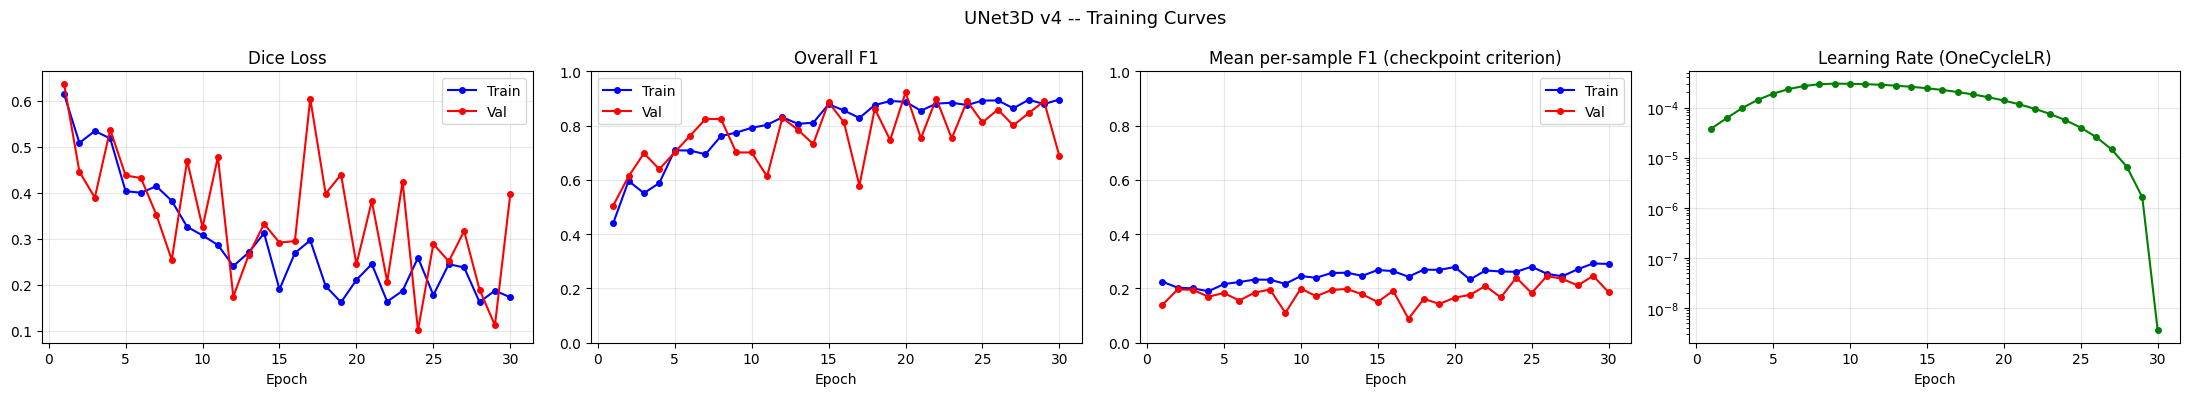

In [14]:
epochs = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 4, figsize=(22, 4))

axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train', markersize=4)
axes[0].plot(epochs, history['val_loss'],   'r-o', label='Val',   markersize=4)
axes[0].set_title('Dice Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history['train_F1'], 'b-o', label='Train', markersize=4)
axes[1].plot(epochs, history['val_F1'],   'r-o', label='Val',   markersize=4)
axes[1].set_title('Overall F1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs, history['train_mF1'], 'b-o', label='Train', markersize=4)
axes[2].plot(epochs, history['val_mF1'],   'r-o', label='Val',   markersize=4)
axes[2].set_title('Mean per-sample F1 (checkpoint criterion)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylim(0, 1)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

axes[3].plot(epochs, history['lr'], 'g-o', markersize=4)
axes[3].set_title('Learning Rate (OneCycleLR)')
axes[3].set_xlabel('Epoch')
axes[3].set_yscale('log')
axes[3].grid(True, alpha=0.3)

plt.suptitle('UNet3D v4 -- Training Curves', fontsize=13)
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves_v4.png'), dpi=150, bbox_inches='tight')
plt.show()

## Quick validation on best checkpoint

Reload the best checkpoint and run a full pass over the val set
to confirm the saved weights match the best epoch's metrics.

In [15]:
# Reload best checkpoint
eval_model = UNet3D(in_channels=CHANS_PER_STEP, base_ch=BASE_CH, n_classes=2).to(device)
eval_model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
eval_model.eval()

val_metrics = FireMetrics()
with torch.no_grad():
    for x, y in tqdm(val_loader, desc='Val eval'):
        x, y = x.to(device), y.to(device)
        xp, H_orig, W_orig = pad_to_multiple(x)
        with make_autocast():
            logits = eval_model(xp)
        logits = logits[:, :, :H_orig, :W_orig]
        val_metrics.update(logits, y)

print(f'Val F1  : {val_metrics.F1:.4f}')
print(f'Val IoU : {val_metrics.IoU:.4f}')
print(f'Val mF1 : {val_metrics.mF1:.4f}')

Val eval:   0%|          | 0/6 [00:00<?, ?it/s]

Val F1  : 0.8759
Val IoU : 0.7791
Val mF1 : 0.2021


## Output files

Upload these four files as a Kaggle dataset before running the inference notebook:

- `unet3d_v4_ba_best.pt`   -- best model weights
- `norm_stats_v4.npz`      -- normalisation statistics
- `run_meta_v4.json`       -- split info and hyperparameters
- `history_v4.json`        -- full training history

In [16]:
print('Training notebook complete.')
print('=' * 60)
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    if not os.path.isfile(fpath):
        continue
    size  = os.path.getsize(fpath)
    unit  = 'KB' if size < 1024**2 else 'MB'
    val   = size/1024 if unit=='KB' else size/1024**2
    print(f'  {fname:<50} {val:>7.1f} {unit}')

Training notebook complete.
  __notebook__.ipynb                                   291.1 KB
  eda_stats_v4.png                                      62.7 KB
  history_v4.json                                        5.5 KB
  norm_stats_v4.npz                                      1.4 KB
  run_meta_v4.json                                       3.5 KB
  training_curves_v4.png                               157.6 KB
  unet3d_v4_ba_best.pt                                  89.9 MB
  unet3d_v4_ba_last.pt                                  89.9 MB
